Our Imports,
witch include data analysing and processing librarys 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold,GridSearchCV 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from hmeasure import h_score
from imblearn.ensemble import BalancedRandomForestClassifier



Here we preprocess our Data and check for nulls , nan and structure of our data:

In [2]:

dta = pd.read_csv("Training Data.csv")
print(dta.head())
print(dta.describe())
dta.info()
print(dta.isnull().sum())# checking for missing values
print(dta.duplicated().sum())#checking for duplications
#dta = dta.drop_duplicates() #there are no duplicates in the data and this line is unnecessary, but I'll leave it here anyway
print(dta.isna().value_counts()) #to check for na values
print(dta.shape)


   Id   Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0   1  1303834   23           3         single          rented            no   
1   2  7574516   40          10         single          rented            no   
2   3  3991815   66           4        married          rented            no   
3   4  6256451   41           2         single          rented           yes   
4   5  5768871   47          11         single          rented            no   

            Profession                 CITY           STATE  CURRENT_JOB_YRS  \
0  Mechanical_engineer                 Rewa  Madhya_Pradesh                3   
1   Software_Developer             Parbhani     Maharashtra                9   
2     Technical_writer            Alappuzha          Kerala                4   
3   Software_Developer          Bhubaneswar          Odisha                2   
4        Civil_servant  Tiruchirappalli[10]      Tamil_Nadu                3   

   CURRENT_HOUSE_YRS  Risk_Flag  
0   

And here's some plots to show,
Imbalance:

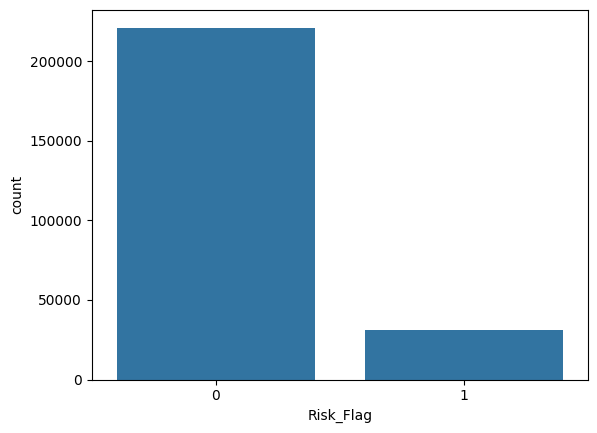

In [3]:

sns.countplot(x='Risk_Flag',data=dta)
plt.show()


As you can see we do infact have a huge imbalance problem which we will solve.

Risk vs Income:

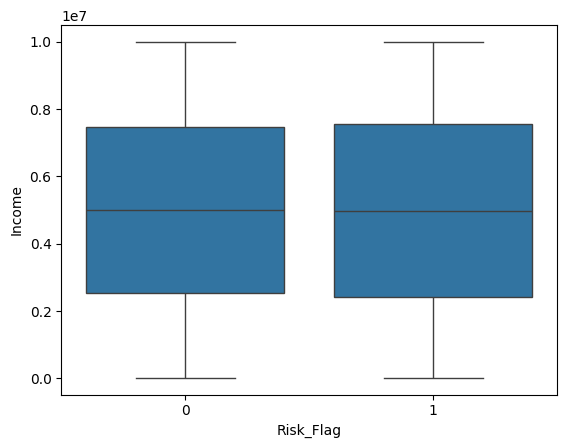

In [4]:

sns.boxplot(x='Risk_Flag',y='Income',data=dta)
plt.show()


Age Distribution:

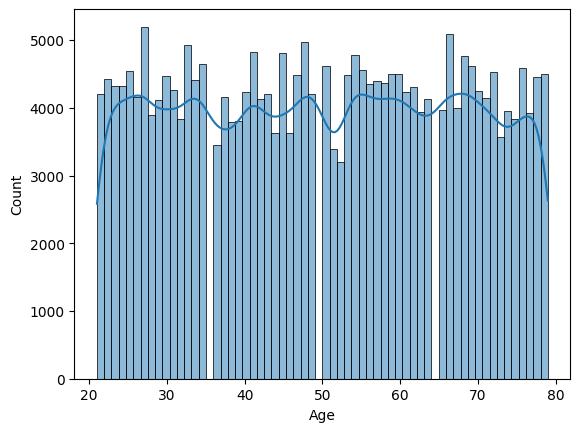

In [5]:

sns.histplot(dta['Age'],kde=True)
plt.show()


For outliers we can also take a look at these boxplots:

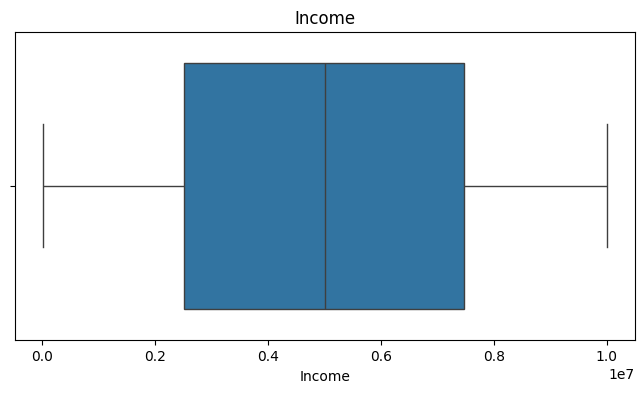

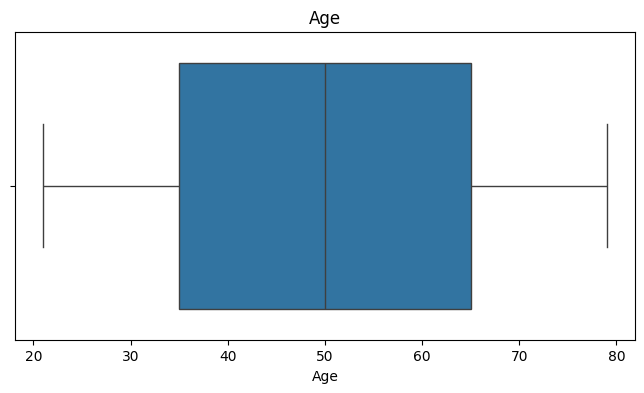

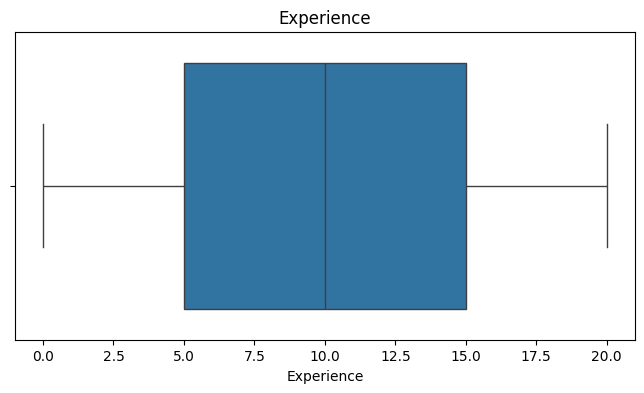

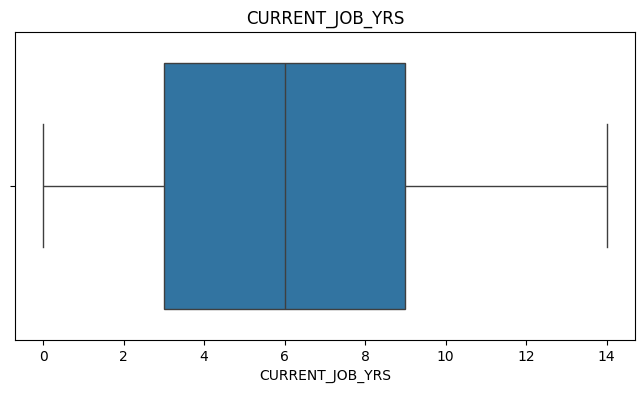

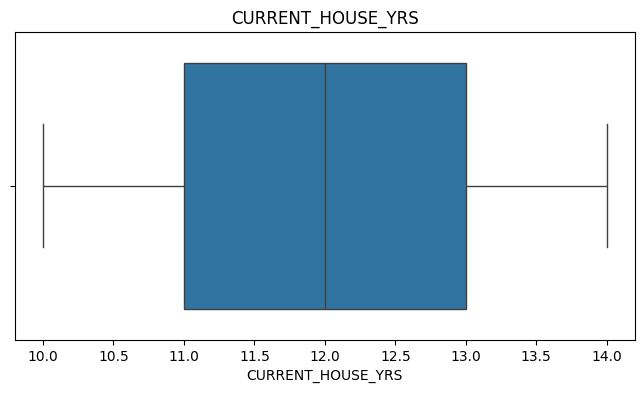

In [6]:
ncols = ['Income','Age','Experience','CURRENT_JOB_YRS','CURRENT_HOUSE_YRS']
for col in ncols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=dta[col])
    plt.title(col)
    plt.show()

As for loading the data:

In [7]:


X = dta.drop(columns=['Risk_Flag','Id'])#Id is just an identifier
Y = dta['Risk_Flag']

trax , tex , tray , tey = train_test_split(X,Y,test_size=0.2,random_state=42)
rus = RandomUnderSampler(random_state=42)
resX,resY = rus.fit_resample(X,Y)



Now beacuse of the huge imbalance that we have with the dataset I'll resample the data using multiple tecniques,

In [8]:


class FrequencyEncoder(BaseEstimator, TransformerMixin):#custom defined encoding less effective than Target but safer
    def __init__(self):
        self.freq_map = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.freq_map = {}
        for col in X.columns:
            self.freq_map[col] = X[col].value_counts(normalize=True)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].map(self.freq_map[col]).fillna(0)
        return X


Encoding choices:

In [9]:

# numcols = ['Income', 'Age'] not needed with forest
bincols = ['Married/Single','Car_Ownership'] # ==> Binary encoding
hotcols = ['House_Ownership']# ==> OneHot encoding
catcols = ['Profession','CITY','STATE']# ==> Frequency/Count encoding or Target


In [10]:

# trax['Married/Single'] = trax['Married/Single'].map({'married':1,'single':0}) custom encodings
# trax['Car_Ownership'] = trax['Car_Ownership'].map({'yes':1,'no':0})


Developing the model and cross validation:

In [11]:



prepros = ColumnTransformer(transformers=[
    ('bin',OrdinalEncoder(),bincols),
    ('hot',OneHotEncoder(handle_unknown='ignore'),hotcols),
    ('cats',TargetEncoder(),catcols)
], remainder='passthrough')


rfmod = imPipeline(steps=[
    ('prepros',prepros),
    ('rus', RandomUnderSampler(random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('classifier',BalancedRandomForestClassifier(n_estimators=130,class_weight='balanced',random_state=42))
])

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
valscore = cross_val_score(
    rfmod,
    resX,
    resY,
    cv=cv,
    scoring='f1'
)
print(valscore)


[0.84743731 0.84881858 0.84231779 0.84330312 0.84752555 0.84042553]


You can see the scores above for f1-scores

And now for the other metrics and threshold:

In [12]:

rfmod.fit(resX, resY)
# Predicting probabilities on test and evaluating the model
proba = rfmod.predict_proba(tex)[:, 1]#1 is to select the positive(1 class)
# roc_auc score
roctest = roc_auc_score(tey, proba)
print(f'ROC AUC Score on test set: {roctest:.4f}')
predytest = rfmod.predict(tex)
print('Classification Report on test set:')
print(classification_report(tey, predytest))

thresh = 0.77 # ===> higher:more precision, lower: more recall
pred = (proba >= thresh).astype(int)
print(f'Classification Report with thresholding at {thresh}:')
print(classification_report(tey, pred))



ROC AUC Score on test set: 0.9579
Classification Report on test set:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94     44147
           1       0.55      1.00      0.71      6253

    accuracy                           0.90     50400
   macro avg       0.77      0.94      0.82     50400
weighted avg       0.94      0.90      0.91     50400

Classification Report with thresholding at 0.77:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     44147
           1       0.63      0.90      0.74      6253

    accuracy                           0.92     50400
   macro avg       0.81      0.91      0.85     50400
weighted avg       0.94      0.92      0.93     50400



And for optimizing the model:

In [13]:
param_grid = {
    'classifier__n_estimators': [100,130,160,200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}
gs = GridSearchCV(rfmod, param_grid, cv=3, scoring='f1', n_jobs=-1)
gs.fit(resX, resY)
print(gs.best_params_)

{'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 160}


Despite the hyperparameter the original parameters proved to be better.(further testing can be effective but unfortunately my system can't handle it)

And now for the H-measure and Liftcurve metrics:

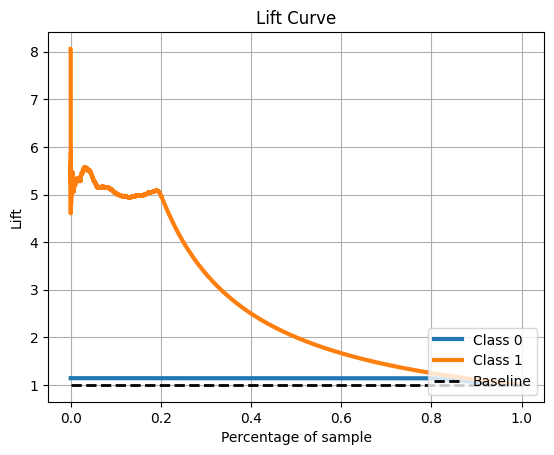

H-Score on test set: 0.8200


In [ ]:
import numpy as np
import scipy as sp
sp.interp = np.interp
from scikitplot.metrics import plot_lift_curve
proba_full = rfmod.predict_proba(tex)
plot_lift_curve(tey, proba_full)
plt.show()
if hasattr(tey, "to_numpy"):
    tey = tey.to_numpy()
hscore = h_score(tey, proba_full[:, 1])
print(f'H-Score on test set: {hscore:.4f}')


And now for the analysis on the test data and visualizations:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 28000 non-null  int64 
 1   Income             28000 non-null  int64 
 2   Age                28000 non-null  int64 
 3   Experience         28000 non-null  int64 
 4   Married/Single     28000 non-null  object
 5   House_Ownership    28000 non-null  object
 6   Car_Ownership      28000 non-null  object
 7   Profession         28000 non-null  object
 8   CITY               28000 non-null  object
 9   STATE              28000 non-null  object
 10  CURRENT_JOB_YRS    28000 non-null  int64 
 11  CURRENT_HOUSE_YRS  28000 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 2.6+ MB
   ID   Income  Age  Experience Married/Single House_Ownership Car_Ownership  \
0   1  7393090   59          19         single          rented            no   
1   2  1215004   25    

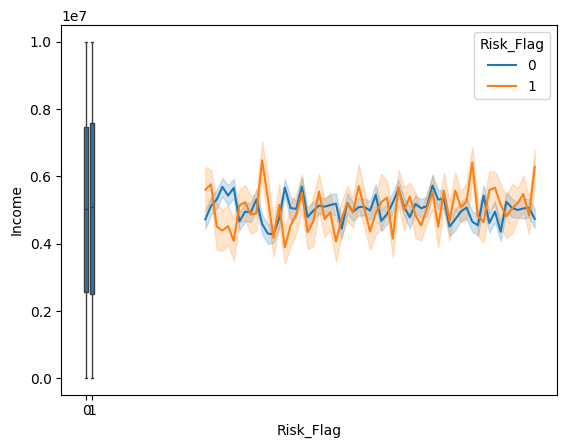

In [15]:

testdta = pd.read_csv("Test Data.csv")
testdta.info()
TX = testdta.drop(columns=['ID'])
tepred = rfmod.predict(TX)
output = pd.DataFrame({'Risk_Flag': tepred})
andata = pd.concat([testdta, output], axis=1)
print(andata.head())
sns.boxplot(x='Risk_Flag',y='Income',data=andata)
sns.lineplot(x='Age',y='Income',hue='Risk_Flag',data=andata)
plt.show()

In [17]:
rf = rfmod.named_steps['classifier']
importance = rf.feature_importances_
pre = rfmod.named_steps['prepros']
feature_names = pre.get_feature_names_out()
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importance})
feat_imp = feat_imp.sort_values('importance', ascending=False)
print(feat_imp.head(10))


                         feature  importance
6                     cats__CITY    0.184912
8              remainder__Income    0.164674
9                 remainder__Age    0.136136
5               cats__Profession    0.132737
10         remainder__Experience    0.094546
7                    cats__STATE    0.094485
11    remainder__CURRENT_JOB_YRS    0.082378
12  remainder__CURRENT_HOUSE_YRS    0.060194
1             bin__Car_Ownership    0.020478
0            bin__Married/Single    0.013371
